# House Price Prediction - Random Forest Regressor
**Dataset:** Kaggle House Prices Dataset  
**Link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data  
**Algorithm:** Random Forest Regressor  
**Metrics:** MAE, RMSE, R²

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [26]:
# Load dataset
df = pd.read_csv("../../data/train.csv")

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()


Dataset Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis (EDA)

In [27]:
# Basic statistics
print('Dataset Info:')
print(df.info())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overa

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


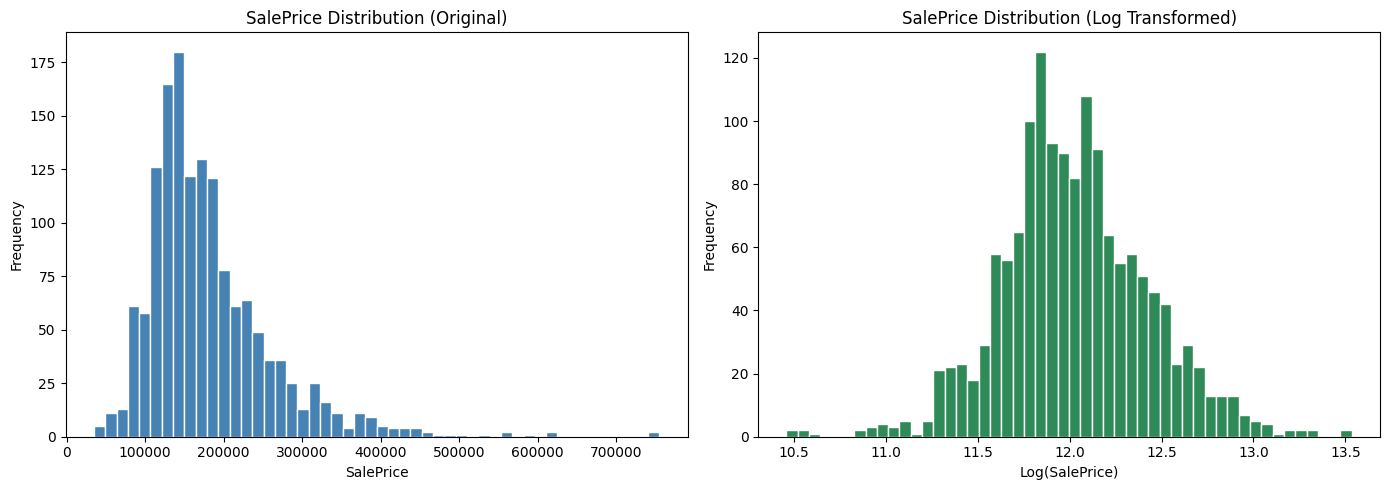

In [28]:
# Distribution of target variable (SalePrice)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before log transformation
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

# After log transformation
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log Transformed)')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('saleprice_distribution.png', dpi=150)
plt.show()

In [29]:
# Correlation heatmap of numeric features with SalePrice
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

# Top 15 correlated features with SalePrice
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(15)
print('Top 15 Features Correlated with SalePrice:')
print(top_corr)

Top 15 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


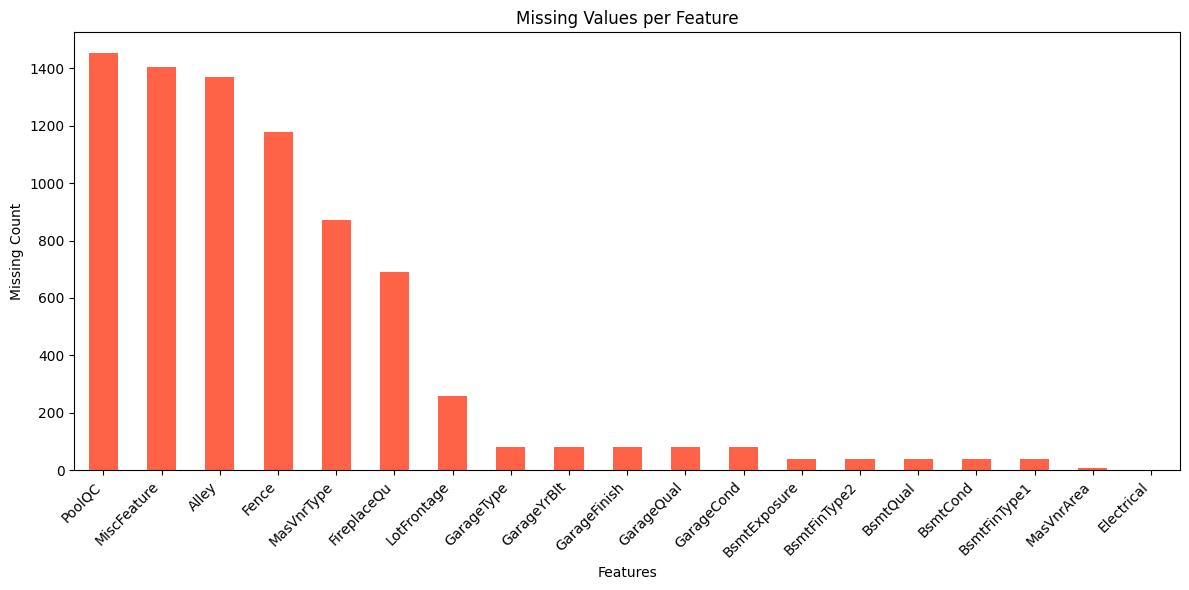

Total features with missing values: 19


In [30]:
# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Feature')
plt.xlabel('Features')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

print(f'Total features with missing values: {len(missing)}')

## 4. Data Preprocessing

In [31]:
# Drop the ID column as it's not a predictive feature
df.drop('Id', axis=1, inplace=True)

# Apply log transformation to target variable to reduce skewness
df['SalePrice'] = np.log1p(df['SalePrice'])

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print('Feature Matrix Shape:', X.shape)
print('Target Shape:', y.shape)

Feature Matrix Shape: (1460, 79)
Target Shape: (1460,)


In [32]:
# -------------------------------------------------------
# Handle Missing Values
# -------------------------------------------------------

# Categorical columns: fill with 'None' (absence of feature)
cat_cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_cols_none:
    if col in X.columns:
        X[col] = X[col].fillna('None')

# Categorical columns: fill with mode (most frequent)
cat_cols_mode = ['Electrical', 'MSZoning', 'KitchenQual', 'Exterior1st',
                 'Exterior2nd', 'Functional', 'SaleType']
for col in cat_cols_mode:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])

# Numeric columns: fill with 0 (no feature present)
num_cols_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_cols_zero:
    if col in X.columns:
        X[col] = X[col].fillna(0)

# LotFrontage: fill with median per neighborhood (similar houses in area)
X['LotFrontage'] = X.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

print('Missing values after cleaning:', X.isnull().sum().sum())

Missing values after cleaning: 0


In [33]:
# -------------------------------------------------------
# Feature Engineering
# -------------------------------------------------------

# Create new meaningful features
X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']  # Total square footage
X['TotalBath'] = (X['FullBath'] + 0.5 * X['HalfBath'] +
                  X['BsmtFullBath'] + 0.5 * X['BsmtHalfBath'])     # Total bathrooms
X['HouseAge'] = X['YrSold'] - X['YearBuilt']                       # Age at time of sale
X['RemodAge'] = X['YrSold'] - X['YearRemodAdd']                    # Years since remodel

print('New features added: TotalSF, TotalBath, HouseAge, RemodAge')
print('Updated Feature Matrix Shape:', X.shape)

New features added: TotalSF, TotalBath, HouseAge, RemodAge
Updated Feature Matrix Shape: (1460, 83)


In [34]:
# -------------------------------------------------------
# Encode Categorical Variables
# -------------------------------------------------------

# Label encode all remaining categorical columns
# (Random Forest handles label-encoded categoricals well)
label_encoders = {}
cat_features = X.select_dtypes(include=['object','string']).columns.tolist()

for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le  # Store encoder for potential inverse transform

print(f'Encoded {len(cat_features)} categorical features')
print('Final Feature Matrix Shape:', X.shape)

Encoded 43 categorical features
Final Feature Matrix Shape: (1460, 83)


## 5. Train-Test Split

In [35]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)

Training set size: (1168, 83)
Test set size:     (292, 83)


## 6. Background & Justification: Random Forest

**Random Forest** is an ensemble learning method that builds multiple decision trees during training and outputs the **mean prediction** of all individual trees for regression tasks.

### Why Random Forest for House Price Prediction?
- Handles high-dimensional data well (80+ features)
- Robust to outliers and noise in the data
- Handles non-linear relationships between features and price
- Provides feature importance scores for interpretability
- Resistant to overfitting compared to a single decision tree

### Key Hyperparameters
| Parameter | Description |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth of each tree |
| `min_samples_split` | Minimum samples required to split a node |
| `max_features` | Number of features considered at each split |

## 7. Train the Random Forest Model

In [36]:
# -------------------------------------------------------
# Baseline Random Forest Model
# -------------------------------------------------------
rf_baseline = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    random_state=42,     # For reproducibility
    n_jobs=-1            # Use all CPU cores
)

rf_baseline.fit(X_train, y_train)
print('Baseline Random Forest trained successfully.')

Baseline Random Forest trained successfully.


In [37]:
# -------------------------------------------------------
# Hyperparameter Tuning with GridSearchCV
# -------------------------------------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# Use 5-fold cross-validation, optimise for RMSE
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV RMSE:   ', -grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best CV RMSE:    0.13908263160505246


In [38]:
# Train final model with best hyperparameters
best_rf = grid_search.best_estimator_
print('Final model trained with best parameters.')

Final model trained with best parameters.


## 8. Evaluation & Results

In [39]:
# -------------------------------------------------------
# Evaluation Function
# -------------------------------------------------------
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model'):
    """
    Evaluate a regression model on train and test sets.
    Returns predictions and prints MAE, RMSE, and R2 scores.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # NOTE: Predictions are in log scale; convert back to original scale
    y_train_orig = np.expm1(y_train)
    y_test_orig  = np.expm1(y_test)
    y_train_pred_orig = np.expm1(y_train_pred)
    y_test_pred_orig  = np.expm1(y_test_pred)

    print(f'\n========== {model_name} Evaluation ==========')
    print(f'  Train MAE  : ${mean_absolute_error(y_train_orig, y_train_pred_orig):,.0f}')
    print(f'  Test  MAE  : ${mean_absolute_error(y_test_orig,  y_test_pred_orig):,.0f}')
    print(f'  Train RMSE : ${np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig)):,.0f}')
    print(f'  Test  RMSE : ${np.sqrt(mean_squared_error(y_test_orig,  y_test_pred_orig)):,.0f}')
    print(f'  Train R²   : {r2_score(y_train_orig, y_train_pred_orig):.4f}')
    print(f'  Test  R²   : {r2_score(y_test_orig,  y_test_pred_orig):.4f}')

    return y_test_pred_orig, y_test_orig


# Evaluate baseline model
_, _ = evaluate_model(rf_baseline, X_train, X_test, y_train, y_test, 'Baseline RF')

# Evaluate tuned model
y_pred_final, y_actual = evaluate_model(best_rf, X_train, X_test, y_train, y_test, 'Tuned RF')


========== Baseline RF Evaluation ==========
  Train MAE  : $6,231
  Test  MAE  : $17,117
  Train RMSE : $10,422
  Test  RMSE : $28,963
  Train R²   : 0.9818
  Test  R²   : 0.8906

========== Tuned RF Evaluation ==========
  Train MAE  : $7,811
  Test  MAE  : $16,933
  Train RMSE : $14,338
  Test  RMSE : $31,594
  Train R²   : 0.9655
  Test  R²   : 0.8699


In [40]:
# -------------------------------------------------------
# 5-Fold Cross Validation on Tuned Model
# -------------------------------------------------------
cv_scores = cross_val_score(
    best_rf, X, y,
    cv=5,
    scoring='r2'
)

print('Cross-Validation R² Scores:', cv_scores.round(4))
print(f'Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² Scores: [0.8931 0.8764 0.8762 0.8819 0.8644]
Mean CV R²: 0.8784 ± 0.0093


## 9. Visualizations

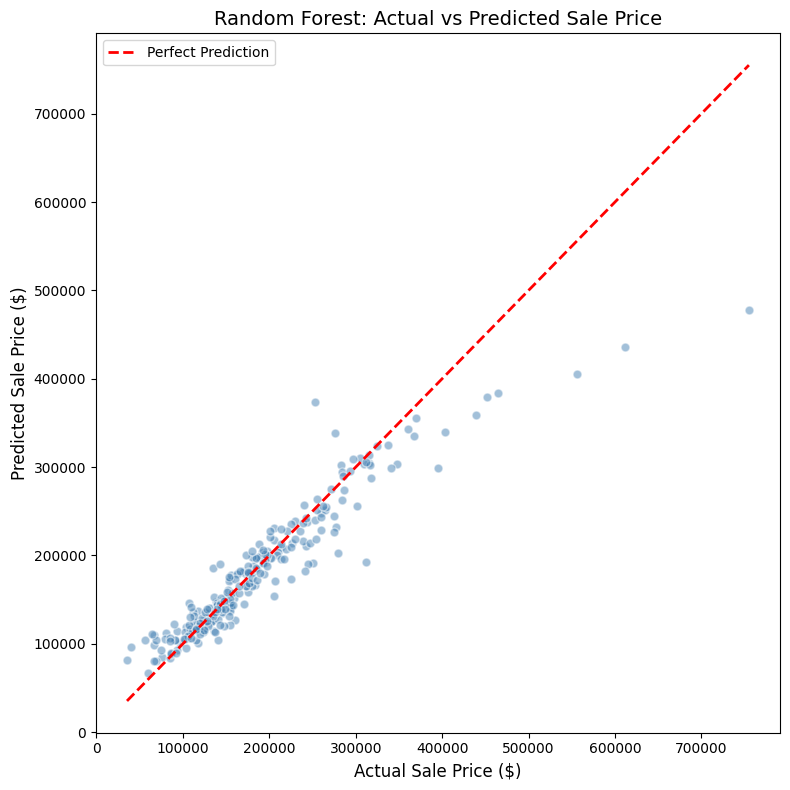

In [41]:
# -------------------------------------------------------
# Plot 1: Actual vs Predicted Prices
# -------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred_final, alpha=0.5, color='steelblue', edgecolors='white', s=40)

# Perfect prediction line
min_val = min(y_actual.min(), y_pred_final.min())
max_val = max(y_actual.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title('Random Forest: Actual vs Predicted Sale Price', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

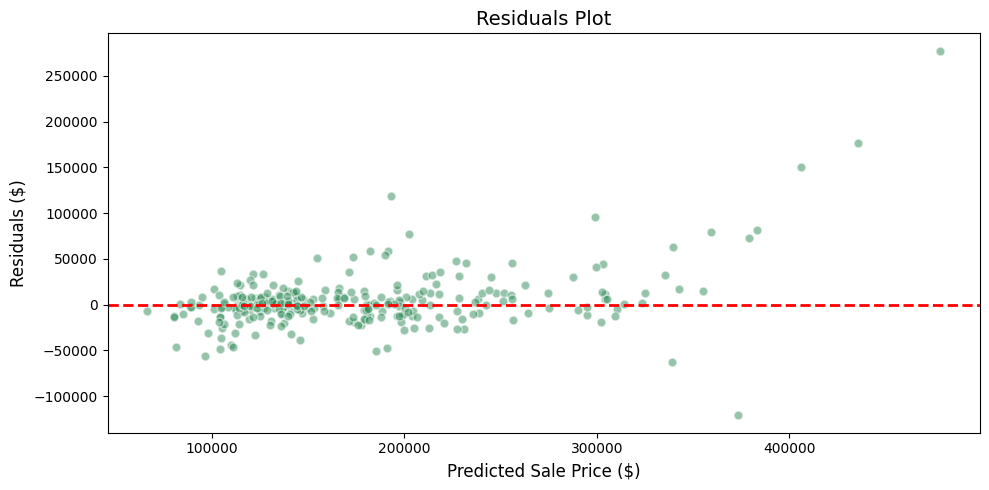

In [42]:
# -------------------------------------------------------
# Plot 2: Residuals Plot
# -------------------------------------------------------
residuals = y_actual - y_pred_final

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_final, residuals, alpha=0.5, color='seagreen', edgecolors='white', s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sale Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residuals Plot', fontsize=14)
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=150)
plt.show()

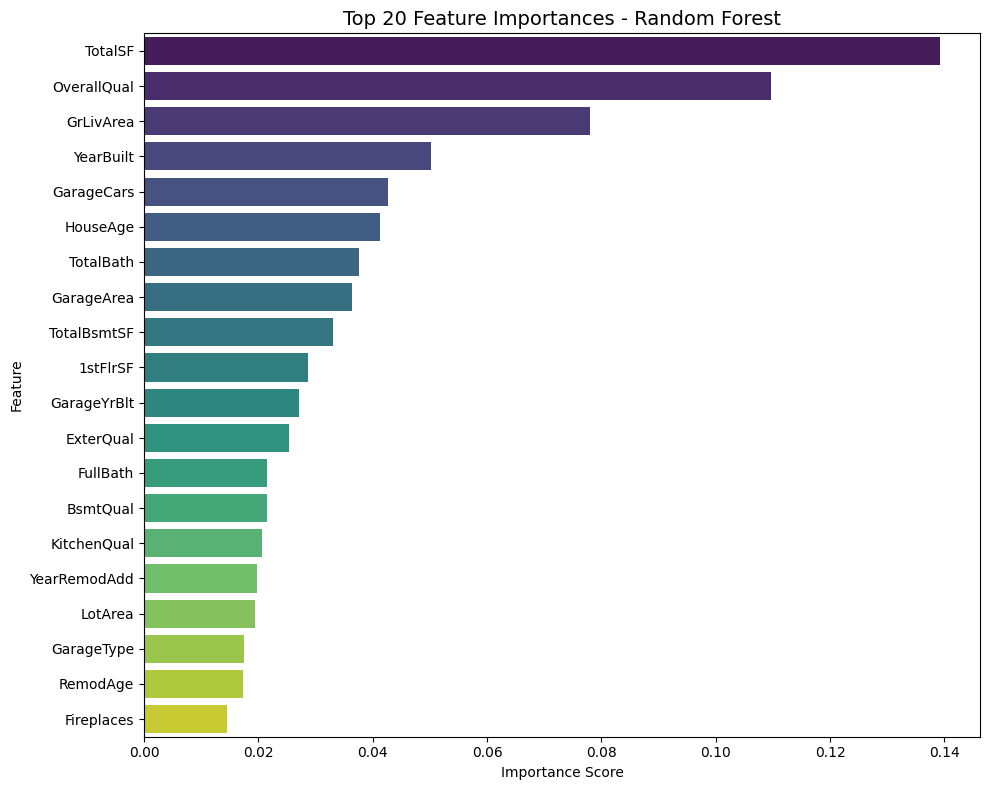

Top 5 Most Important Features:
    Feature  Importance
    TotalSF    0.139263
OverallQual    0.109661
  GrLivArea    0.078008
  YearBuilt    0.050227
 GarageCars    0.042652


In [44]:
# -------------------------------------------------------
# Plot 3: Top 20 Feature Importances
# -------------------------------------------------------
importances = best_rf.feature_importances_
feature_names = X.columns.tolist()

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 20 Feature Importances - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

print('Top 5 Most Important Features:')
print(feat_imp_df.head(5).to_string(index=False))

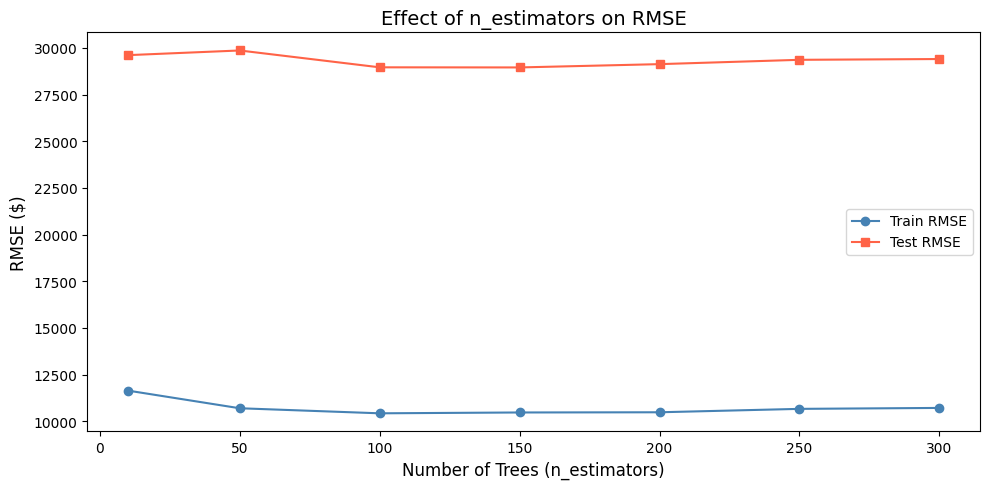

In [45]:
# -------------------------------------------------------
# Plot 4: Effect of n_estimators on RMSE
# -------------------------------------------------------
n_estimators_range = [10, 50, 100, 150, 200, 250, 300]
train_rmse_list = []
test_rmse_list  = []

for n in n_estimators_range:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)

    train_pred = np.expm1(rf_temp.predict(X_train))
    test_pred  = np.expm1(rf_temp.predict(X_test))

    train_rmse_list.append(np.sqrt(mean_squared_error(np.expm1(y_train), train_pred)))
    test_rmse_list.append(np.sqrt(mean_squared_error(np.expm1(y_test),  test_pred)))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, train_rmse_list, marker='o', label='Train RMSE', color='steelblue')
plt.plot(n_estimators_range, test_rmse_list,  marker='s', label='Test RMSE',  color='tomato')
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('RMSE ($)', fontsize=12)
plt.title('Effect of n_estimators on RMSE', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('n_estimators_vs_rmse.png', dpi=150)
plt.show()